### Import data

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
import scipy.stats

# import lgbmclassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
# import cross_val_predict


In [3]:
# data types for read_csv: client_catg = category, disrict = category, creation_date = parse date,
# tarif_type_mode = category, has_multi_invoice_same_day_nanmax = category, region = category
train_res = pd.read_csv('data/created_train_res.csv', dtype={'client_catg': 'category', 'disrict': 'category', 'tarif_type_mode': 'category', 'has_multi_invoice_same_day_nanmax': 'category', 'region': 'category'}, parse_dates=['creation_date'], dayfirst=True, low_memory=False)
val = pd.read_csv('data/created_val.csv', dtype={'client_catg': 'category', 'disrict': 'category', 'tarif_type_mode': 'category', 'has_multi_invoice_same_day_nanmax': 'category', 'region': 'category'}, parse_dates=['creation_date'], dayfirst=True, low_memory=False)
test = pd.read_csv(f'data/created_test.csv', dtype={'client_catg': 'category', 'disrict': 'category', 'tarif_type_mode': 'category', 'has_multi_invoice_same_day_nanmax': 'category', 'region': 'category'}, parse_dates=['creation_date'], dayfirst=True, low_memory=False)

sample_submission = pd.read_csv(f'results/SampleSubmission.csv', low_memory=False)


In [4]:
train_res['account_age'] = (pd.Timestamp('today') - train_res.loc[:, 'creation_date']).dt.days
val['account_age'] = (pd.Timestamp('today') - val.loc[:, 'creation_date']).dt.days
test['account_age'] = (pd.Timestamp('today') - test.loc[:, 'creation_date']).dt.days

In [5]:
# count null values
def count_null_values(df):
    null_counts = df.isnull().sum()
    return null_counts

# count null values in train_res, val, and test
print(count_null_values(train_res))
print(count_null_values(val))
print(count_null_values(test))

disrict                                  0
client_id                                0
client_catg                              0
region                                   0
creation_date                            0
target                                   0
1transactions_count                      2
gap_days_nanstd                        542
consumption_per_month_nanstd           252
frac_time_lvl4_nanmax                    2
consumption_per_month_scaled_nanstd    252
active_nanmean                           2
counter_statue_nanstd                  252
reading_remarque_nanstd                252
tarif_type_mode                          2
index_diff_nanstd                      252
has_multi_invoice_same_day_nanmax        2
used_lvl4_sum                            2
account_age                              0
dtype: int64
disrict                                   0
client_id                                 0
client_catg                               0
region                                

In [6]:
val.dtypes

disrict                                      category
client_id                                      object
client_catg                                  category
region                                       category
creation_date                          datetime64[ns]
target                                        float64
1transactions_count                           float64
gap_days_nanstd                               float64
consumption_per_month_nanstd                  float64
frac_time_lvl4_nanmax                         float64
consumption_per_month_scaled_nanstd           float64
active_nanmean                                float64
counter_statue_nanstd                         float64
reading_remarque_nanstd                       float64
tarif_type_mode                              category
index_diff_nanstd                             float64
has_multi_invoice_same_day_nanmax            category
used_lvl4_sum                                 float64
account_age                 

In [7]:
train_res.nunique()

disrict                                    4
client_id                              12106
client_catg                                3
region                                    24
creation_date                           4908
target                                     2
1transactions_count                      182
gap_days_nanstd                        10981
consumption_per_month_nanstd           11691
frac_time_lvl4_nanmax                    625
consumption_per_month_scaled_nanstd    11371
active_nanmean                          1158
counter_statue_nanstd                   1417
reading_remarque_nanstd                 8420
tarif_type_mode                           10
index_diff_nanstd                      11677
has_multi_invoice_same_day_nanmax          2
used_lvl4_sum                             62
account_age                             4908
dtype: int64

In [8]:
# Checking for missing values
missing = pd.DataFrame(train_res.isnull().sum(), columns=["Amount"])
missing['Percentage'] = round((missing['Amount']/train_res.shape[0])*100, 2)
missing[missing['Amount'] != 0]

,Amount,Percentage
1transactions_count,2,0.02
gap_days_nanstd,542,4.48
consumption_per_month_nanstd,252,2.08
frac_time_lvl4_nanmax,2,0.02
consumption_per_month_scaled_nanstd,252,2.08
active_nanmean,2,0.02
counter_statue_nanstd,252,2.08
reading_remarque_nanstd,252,2.08
tarif_type_mode,2,0.02
index_diff_nanstd,252,2.08


In [9]:
print(train_res.shape, val.shape, test.shape)

(12106, 19) (27099, 19) (58069, 18)


In [10]:
# show rows in train_res where 1transactions_count == nan 
print(train_res[train_res['1transactions_count'].isnull()])
# remove from train_res rows where 1transactions_count == nan
train_res = train_res[~train_res['1transactions_count'].isnull()]
print(train_res.shape)

     disrict            client_id client_catg region creation_date  target  \
2339      63  train_Client_131550          51    312    2018-03-12     0.0   
3816      62  train_Client_126995          51    309    2002-05-31     0.0   

      1transactions_count  gap_days_nanstd  consumption_per_month_nanstd  \
2339                  NaN              NaN                           NaN   
3816                  NaN              NaN                           NaN   

      frac_time_lvl4_nanmax  consumption_per_month_scaled_nanstd  \
2339                    NaN                                  NaN   
3816                    NaN                                  NaN   

      active_nanmean  counter_statue_nanstd  reading_remarque_nanstd  \
2339             NaN                    NaN                      NaN   
3816             NaN                    NaN                      NaN   

     tarif_type_mode  index_diff_nanstd has_multi_invoice_same_day_nanmax  \
2339             NaN                N

In [11]:
# show rows where reading_remarque_nanstd == nan
print(train_res[train_res['reading_remarque_nanstd'].isnull()])

      disrict           client_id client_catg region creation_date  target  \
48         60  train_Client_58206          11    101    2010-11-26     0.0   
157        60  train_Client_17126          11    101    2008-11-22     0.0   
158        60  train_Client_32202          11    101    2000-12-20     0.0   
226        69  train_Client_58543          11    104    1986-07-01     0.0   
274        63  train_Client_96075          11    311    1995-06-21     0.0   
...       ...                 ...         ...    ...           ...     ...   
10680      63  train_Client_29199          11    308    2016-05-31     1.0   
10705      69   train_Client_7060          11    105    2016-10-11     1.0   
11193      60  train_Client_47906          11    101    2015-02-23     1.0   
11294      63  train_Client_87905          11    306    2016-04-14     1.0   
11866      60  train_Client_37016          11    101    2013-09-18     1.0   

       1transactions_count  gap_days_nanstd  consumption_per_mo

##### drop columns not needed for modelling (on all data sets)

In [12]:
client_id_val = val['client_id']
client_id_test = test['client_id']

drop_columns = ['client_id', 'creation_date', 'disrict', 'gap_days_nanst']
for col in drop_columns:
    if col in train_res.columns:
        train_res.drop([col], axis=1, inplace=True)
    if col in val.columns:
        val.drop([col], axis=1, inplace=True)
    if col in test.columns:
        test.drop([col], axis=1, inplace=True)

In [20]:
train_res.columns

Index(['client_catg', 'region', 'target', '1transactions_count',
       'gap_days_nanstd', 'consumption_per_month_nanstd',
       'frac_time_lvl4_nanmax', 'consumption_per_month_scaled_nanstd',
       'active_nanmean', 'counter_statue_nanstd', 'reading_remarque_nanstd',
       'tarif_type_mode', 'index_diff_nanstd',
       'has_multi_invoice_same_day_nanmax', 'used_lvl4_sum', 'account_age'],
      dtype='object')

In [28]:
# Creating list for categorical features
cat_features = train_res.select_dtypes(include=['category']).columns.tolist()
print(cat_features)

['client_catg', 'region', 'tarif_type_mode', 'has_multi_invoice_same_day_nanmax']


In [ ]:
# Creating list for numerical features
num_features = train_res.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features.remove('target')
print(num_features)

['1transactions_count', 'gap_days_nanstd', 'consumption_per_month_nanstd', 'frac_time_lvl4_nanmax', 'consumption_per_month_scaled_nanstd', 'active_nanmean', 'counter_statue_nanstd', 'reading_remarque_nanstd', 'index_diff_nanstd', 'used_lvl4_sum', 'account_age']


## Build Pipeline

In [ ]:
num_pipeline = Pipeline([
    ('imputer_num', SimpleImputer(strategy='constant', fill_value=0)),
    ('std_scaler', StandardScaler())
])

# Pipeline for categorical features 
cat_pipeline = Pipeline([
    ('imputer_cat', SimpleImputer(strategy='constant', fill_value='missing'))
    #('1hot', OneHotEncoder(handle_unknown='ignore'))
])

In [29]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

## Predictions using Pipeline for SGBMClassifier

In [30]:
pipe_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('lgbm', LGBMClassifier(random_state=42))
])

In [34]:
y_train_predicted = cross_val_predict(pipe_lgbm, train_res.drop('target', axis=1), train_res['target'], cv=5)

[LightGBM] [Info] Number of positive: 4843, number of negative: 4840
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000726 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2580
[LightGBM] [Info] Number of data points in the train set: 9683, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500155 -> initscore=0.000620
[LightGBM] [Info] Start training from score 0.000620
[LightGBM] [Info] Number of positive: 4842, number of negative: 4841
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000812 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2568
[LightGBM] [Info] Number of data points in the train set: 9683, number of used features: 47
[LightGBM] [Info] [binary:

In [35]:
# impoort scores
from sklearn.metrics import accuracy_score, recall_score, precision_score
# Calculating the accuracy for the LogisticRegression Classifier 
print('Cross validation scores:')
print('-------------------------')
print("Accuracy: {:.2f}".format(accuracy_score(train_res['target'], y_train_predicted)))
print("Recall: {:.2f}".format(recall_score(train_res['target'], y_train_predicted)))
print("Precision: {:.2f}".format(precision_score(train_res['target'], y_train_predicted)))

Cross validation scores:
-------------------------
Accuracy: 0.70
Recall: 0.75
Precision: 0.68


In [45]:
pipe_lgbm.get_params()

{'memory': None,
 'steps': [('preprocessor',
   ColumnTransformer(transformers=[('num',
                                    Pipeline(steps=[('imputer_num',
                                                     SimpleImputer(fill_value=0,
                                                                   strategy='constant')),
                                                    ('std_scaler',
                                                     StandardScaler())]),
                                    ['client_catg', 'region',
                                     '1transactions_count', 'gap_days_nanstd',
                                     'consumption_per_month_nanstd',
                                     'frac_time_lvl4_nanmax',
                                     'consumption_per_month_scaled_nanstd',
                                     'active_nanmean', 'counter_statue_nanstd',
                                     'reading_remarque_nanstd', 'tarif_type_mode',
                     

In [50]:
from scipy.stats import uniform, loguniform
# import sp_randint and sp_uniform
import scipy.stats as stats
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distributions
rs_params = {
    'lgbm__num_leaves': stats.randint(50, 1000),
    'lgbm__learning_rate': [0.01, 0.05, 0.1],
    'lgbm__n_estimators': [500, 1000],
    'lgbm__feature_fraction': stats.uniform(0.5, 0.5)
}

# Perform randomized search
random_search = RandomizedSearchCV(
    pipe_lgbm,
    param_distributions=rs_params,
    scoring="roc_auc",
    n_iter=20,
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(train_res.drop('target', axis=1), train_res.target)

[LightGBM] [Warning] feature_fraction is set=0.6872700594236812, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6872700594236812
[LightGBM] [Warning] feature_fraction is set=0.6872700594236812, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6872700594236812
[LightGBM] [Info] Number of positive: 6053, number of negative: 6051
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006870 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2586
[LightGBM] [Info] Number of data points in the train set: 12104, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500083 -> initscore=0.000330
[LightGBM] [Info] Start training from score 0.000330


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer_num',
                                                                                                SimpleImputer(fill_value=0,
                                                                                                              strategy='constant')),
                                                                                               ('std_scaler',
                                                                                                StandardScaler())]),
                                                                               ['client_catg',
                                                                                'region',
                                                                                '1transactions_count',
                                                                                'gap_days_nanstd',
                                                                                'consumption_per_month_nanstd',
                                                                                'frac_time_lvl4_nanmax',
                                                                                'consumption...
                   n_iter=20, n_jobs=-1,
                   param_distributions={'lgbm__feature_fraction': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000028191197390>,
                                        'lgbm__learning_rate': [0.01, 0.05,
                                                                0.1],
                                        'lgbm__n_estimators': [500, 1000],
                                        'lgbm__num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000028191197410>},
                   random_state=42, scoring='roc_auc')

In [51]:
# extract best_params
best_params = random_search.best_params_
print("Best parameters found: ", best_params)

Best parameters found:  {'lgbm__feature_fraction': 0.6872700594236812, 'lgbm__learning_rate': 0.01, 'lgbm__n_estimators': 500, 'lgbm__num_leaves': 156}


In [52]:
# grid search near the best values found by random search
grid_params = {
    'lgbm__num_leaves': [best_params['lgbm__num_leaves'] - 50, best_params['lgbm__num_leaves'], best_params['lgbm__num_leaves'] + 50],
    'lgbm__learning_rate': [best_params['lgbm__learning_rate'] * 0.5, best_params['lgbm__learning_rate'], best_params['lgbm__learning_rate'] * 1.5],
    'lgbm__n_estimators': [best_params['lgbm__n_estimators'] - 100, best_params['lgbm__n_estimators'], best_params['lgbm__n_estimators'] + 100],
    'lgbm__feature_fraction': [best_params['lgbm__feature_fraction'] * 0.9, best_params['lgbm__feature_fraction'], best_params['lgbm__feature_fraction'] * 1.1]
}

grid_search = GridSearchCV(
    pipe_lgbm,
    param_grid=grid_params,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(train_res.drop('target', axis=1), train_res.target)
print("Best parameters found in grid search: ", grid_search.best_params_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Warning] feature_fraction is set=0.6185430534813131, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6185430534813131
[LightGBM] [Warning] feature_fraction is set=0.6185430534813131, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6185430534813131
[LightGBM] [Info] Number of positive: 6053, number of negative: 6051
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002785 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2586
[LightGBM] [Info] Number of data points in the train set: 12104, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500083 -> initscore=0.000330
[LightGBM] [Info] Start training from score 0.000330
Best parameters found in grid search:  {'lgbm__feature_fraction': 0.6185430534813131, 'lgbm__learning_rate': 0.005, 'lgbm__n_estimators': 60

In [53]:
# extract best model
best_model = grid_search.best_estimator_

[LightGBM] [Warning] feature_fraction is set=0.6185430534813131, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6185430534813131
Validation ROC AUC: 0.7783


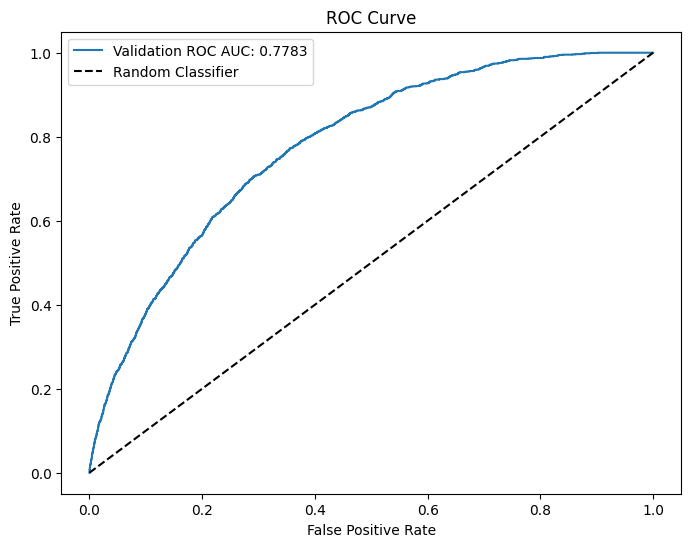

In [54]:
# Predict with the best parameters on val using predict_proba and show ROC_AUC Curve
y_val_proba = best_model.predict_proba(val.drop('target', axis=1))[:, 1]
val_roc_auc = roc_auc_score(val['target'], y_val_proba)
print("Validation ROC AUC: {:.4f}".format(val_roc_auc))

# show ROC curve
fpr, tpr, thresholds = roc_curve(val['target'], y_val_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Validation ROC AUC: {val_roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


Text(0.5, 1.0, 'Top 20 Feature Importances')

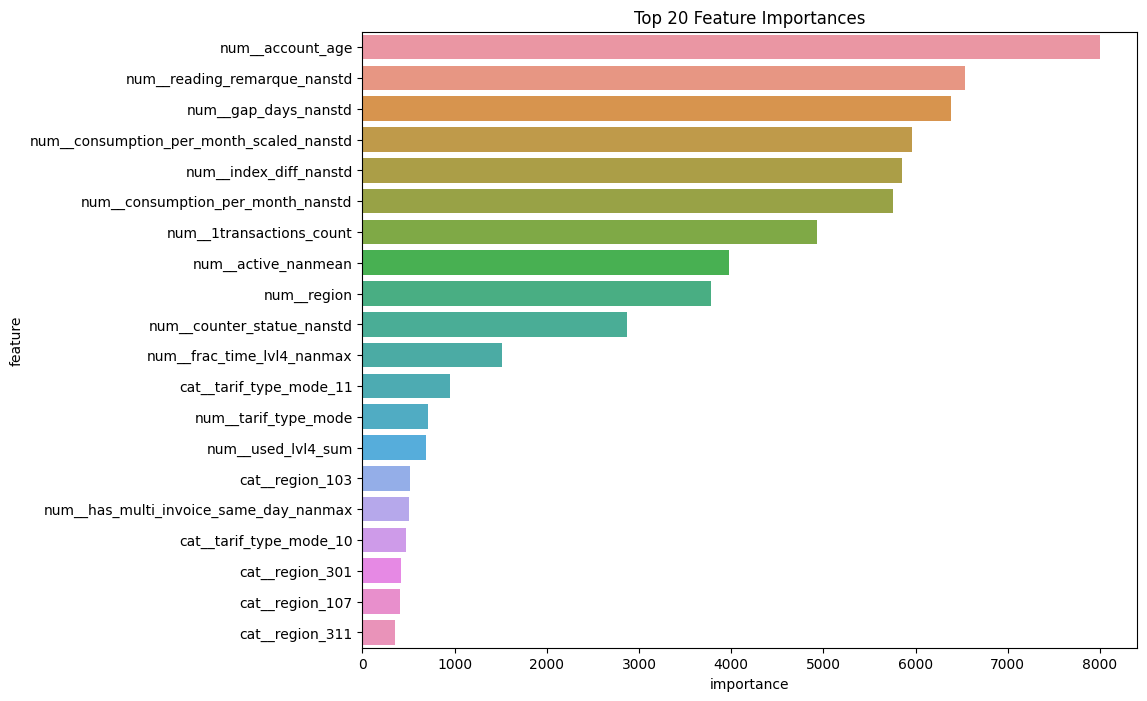

In [60]:
# feature importance on the best model
feature_importances = best_model.named_steps['lgbm'].feature_importances_
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importances')

In [55]:
# predict on test set
y_test_proba = best_model.predict_proba(test)[:, 1]
preds = pd.DataFrame(y_test_proba, columns=['target'])

[LightGBM] [Warning] feature_fraction is set=0.6185430534813131, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6185430534813131


In [56]:
submission = pd.DataFrame(
    {
        'client_id': client_id_test,
        'target': preds['target']
    }
)

submission.head()

,client_id,target
0,test_Client_0,0.643513
1,test_Client_1,0.801722
2,test_Client_10,0.425343
3,test_Client_100,0.457393
4,test_Client_1000,0.454596


In [57]:
submission.to_csv(f'results/submission_eike.csv', index=False)